In [1]:
from composer import *
from bs4 import BeautifulSoup
import requests
import re
import networkx as nx
import spacy
import numpy as np
import math
import time
import pickle
import json
from ipysigma import Sigma

## NLP pour identifier des influences directes via les notices biographiques

In [2]:
"""cette cellule permet de retrouver tous les noms de compositeurs cités dans l'article wikipedia du compositeur d'intérêt et d'en dresser la liste dans un dictionnaire dont les clés sont les id des compositeurs en question"""

def get_person_entities(text):
    nlp = spacy.load("en_core_web_sm")
    doc = nlp(text)
    L=[]
    for ent in doc.ents:
        if ent.label_=='PERSON':
            #print(ent.text, ent.start_char, ent.end_char, ent.label_)
            L.append(ent.text)
    #print(L)
    return L
    
            
def get_wikipedia_page_metadata(name):
    language_code = 'en'
    search_query = name
    number_of_results = 1
    """headers = {
      # 'Authorization': 'Bearer ACCESS_TOKEN',
      'User-Agent': 'APP_NAME (EMAIL_OR_CONTACT_PAGE)'
    }"""
    base_url = 'https://api.wikimedia.org/core/v1/wikipedia/'
    endpoint = '/search/page'
    url = base_url + language_code + endpoint
    parameters = {'q': search_query, 'limit': number_of_results}
    response = requests.get(url, params=parameters)
    dico_response = json.loads(response.text)
    for page in dico_response['pages']:
      display_title = page['title']
      article_url = 'https://' + language_code + '.wikipedia.org/wiki/' + page['key']
      try:
        article_description = page['description']
      except:
        article_description = 'a Wikipedia article'
      try:
        thumbnail_url = 'https:' + page['thumbnail']['url']
      except:
        thumbnail_url = 'https://upload.wikimedia.org/wikipedia/commons/thumb/8/80/Wikipedia-logo-v2.svg/200px-Wikipedia-logo-v2.svg.png'
        

def get_wikipedia_page_text_with_api(title):
    endpoint = "https://en.wikipedia.org/w/api.php"
    params = {
        'action': 'parse',
        'page': title,
        'format': 'json',
        'prop': 'text',
    }

    response = requests.get(endpoint, params=params)
    data = response.json()

    if 'parse' in data:
        html_content = data['parse']['text']['*']
        soup = BeautifulSoup(html_content, 'html.parser')
        text = soup.get_text()
        return text
    else:
        return "Page not found or error occurred"
    
def get_wikipedia_page_text(name,language="en"):
    url = f"https://{language}.wikipedia.org/w/index.php?search={name}"
    page = requests.get(url)
    soup = BeautifulSoup(page.content, "html.parser")
    text=soup.get_text()
    if language =="en" and name+" - Wikipedia" in text:
        return get_wikipedia_page_text(name+" (composer)")
    elif language=="fr" and name+" - Wikipédia" in text:
        return get_wikipedia_page_text(naem+" (compositeur)")
    return text


## filtre pour ne conserver que les noms de compositeurs

In [3]:
def composer_filter_by_dict(list_of_names, dico):
    """filtre les noms qui sont ceux de compositeurs à partir d'un dictionnaire de compositeurs, évite d'avoir à rechercher dans wikidata à chaque fois donc plus rapide mais moins robuste, à compléter peut-être avec le TD qui utilisait des Trie"""
    list_of_names = list(filter(lambda x: x.strip() in dico, list_of_names))
    return list_of_names

#composer_filter_by_dict(["Richard Wagner","Bach","Mozart"],{"Richard Wagner":(1813,1883),"Johann Sebastian Bach":(1685,1750)})
        
def composer_filter(list_of_names):
    compo_dico={}
    for n in list_of_names:
        c_id = find_id(n)
        if c_id not in compo_dico:
            c = is_composer(c_id,n)
            #print(is_composer(n))
            if c is not None :
                compo_dico[c_id]=c
                print(n,"is a composer")
    return compo_dico

#compo_dico=composer_filter(["Bach","Beethoven","Wagner"])
#print(compo_dico)


In [4]:
def find_compositional_influences(name,fr=False):#problème : l'algo saute souvent Beethoven, y compris chez Wagner
    content = get_wikipedia_page_text(name)
    if fr:
        content+=get_wikipedia_page_text(name,"fr")
    persons = get_person_entities(content)
    return(composer_filter(persons))

def build_list_of_influences(enum_of_composers,french=False):
    list_of_influ_dict=[]
    for composer in enum_of_composers:
        list_of_influ_dict.append(find_compositional_influences(composer,fr=french))
    return list_of_influ_dict

#compos = ["André-Ernest-Modeste Grétry","Ernest Chausson","Gabriel Dupont","Paul le Flem"]
#compos = ["Franz Lachner","Jean Cras"]
compos = ["Henri Duparc"]

list_of_dico=build_list_of_influences(compos,True)
print(list_of_dico)

Henri Duparc is a composer
Erreur sur le nom A m
Maurice Duhamel is a composer
Paul Dukas is a composer
Gabriel Dupont is a composer
Jean-Louis Duport is a composer
Gabriel Fauré is a composer
Claude Debussy is a composer
Isaac Albéniz is a composer
Benjamin Godard is a composer
Egidio Duni is a composer
John Dunstaple is a composer
Jacques Duphly is a composer
Erreur sur le nom H o
Chabrier is a composer
Ernest Chausson is a composer
Erreur sur le nom J u
Rita Strohl is a composer
Alexandre Tansman is a composer
Bussine is a composer
Jules Massenet is a composer
Erreur sur le nom J a
Jacques Lamy is a composer
Louis Moreau Gottschalk is a composer
Erreur sur le nom H e
Théodore Ymbert is a composer
Erreur sur le nom l a
Erreur sur le nom R e
Erreur sur le nom l a
Erreur sur le nom L i
Erreur sur le nom l a


In [8]:
"""essayons de qualifier les relations d'influence entre compositeurs plus précisément qu'avec la seule présence de l'un dans la page wikipedia de l'autre"""
"""compléter avec les influences - même peu nombreuses - spécifiées dans wikidata"""
"""penser à prévoir le cas d'un compositeur encore vivant"""
def orienting_with_dates_sparql(list_of_dico,influences={}):
    """returning an adjacency list from the dict of composers appearing in the wiki notice of the first one in the dict; orienting the influence relations when no doubt exists because of birth-death dates"""
    sparql_endpoint = "https://query.wikidata.org/sparql"
    for dico in list_of_dico:
        cpt=0
        for c in dico:
            #if c.birth is None or c.death is None:#à améliorer
            time.sleep(1)  # 0.5s between requests
            query = f"""
                    SELECT ?birth ?death WHERE {{
                        wd:{c} wdt:P569 ?birth.
                        wd:{c} wdt:P570 ?death.
                    }}
                    """
                
            if cpt>0:#the rest of the dict are the composers who may have or have been influenced our musician of interest "compo"
                response = requests.get(sparql_endpoint, params={'query': query, 'format': 'json'})
                print("Status Code:", response.status_code)
                #print("Response Text:", response.text)
                dates_dict = response.json()
                bindings = dates_dict.get("results", {}).get("bindings", [])
                if bindings:
                    birth_date = int(bindings[0].get("birth", {}).get("value").split("-")[0])                                                             #, "Unknown")
                    #c.birth=birth_date
                    death_date = int(bindings[0].get("death", {}).get("value").split("-")[0])
                    #c.death=death_date

                if death_date < birth_date_compo+20:#if the current composer c died at most 20 years after the birth of compo we assume compo could not influence c and that only c influenced compo
                    if c not in influences :
                        influences[c]=[]
                    influences[c].append(compo)
                elif birth_date > death_date_compo-20:#if compo died at most 2O years after the birth of c then we assume only compo could influence c and not the other way around
                    influences[compo].append(c)
                else:#we cannot say anything for sure since they were contemporary so by default we assume they influenced each other 
                    influences[compo].append(c)
                    if c not in influences :
                        influences[c]=[]
                    influences[c].append(compo)

            else:#the first element of the dictionary is the composer we are interested in : "compo"
                compo = c
                if compo not in influences:
                    influences[compo]=[]
                response = requests.get(sparql_endpoint, params={'query': query, 'format': 'json'})
                dates_dict = response.json()
                bindings = dates_dict.get("results", {}).get("bindings", [])
                if bindings:
                    birth_date_compo = int(bindings[0].get("birth", {}).get("value").split("-")[0])
                                                                                 #, "Unknown")
                    #compo.birth=birth_date_compo
                    death_date_compo = int(bindings[0].get("death", {}).get("value").split("-")[0])
                    #compo.death=death_date_compo
                #else:
                #    birth_date_compo = "Unknown"
                #    death_date_compo = "Unknown"
                #print(birth_date_compo,death_date_compo)
                #if birth_date_compo != "Unknown" and death_date_compo != "Unknown"
                cpt+=1
        
    return influences

def orienting_with_dates(list_of_dico,influences={}):
    """returning an adjacency list from the dict of composers appearing in the wiki notice of the first one in the dict; orienting the influence relations when no doubt exists because of birth-death dates"""
    for dico in list_of_dico:
        cpt=0
        for c in dico.values():
            if cpt>0:#the rest of the dict are the composers who may have or have been influenced our musician of interest "compo"
                birth_date = int(c.birth.split("-")[0])
                death_date = int(c.death.split("-")[0])

                if death_date < birth_date_compo+20:#if the current composer c died at most 20 years after the birth of compo we assume compo could not influence c and that only c influenced compo
                    if c not in influences :
                        influences[c]=[]
                    influences[c].append(compo)
                elif birth_date > death_date_compo-20:#if compo died at most 2O years after the birth of c then we assume only compo could influence c and not the other way around
                    influences[compo].append(c)
                else:#we cannot say anything for sure since they were contemporary so by default we assume they influenced each other 
                    influences[compo].append(c)
                    if c not in influences :
                        influences[c]=[]
                    influences[c].append(compo)

            else:#the first element of the dictionary is the composer we are interested in : "compo"
                compo = c
                if compo not in influences:
                    influences[compo]=[]
                #response = requests.get(sparql_endpoint, params={'query': query, 'format': 'json'})
                #dates_dict = response.json()
                #bindings = dates_dict.get("results", {}).get("bindings", [])
                #if bindings:
                birth_date_compo = int(c.birth.split("-")[0])                                                                 #, "Unknown")
                death_date_compo = int(c.death.split("-")[0])
                #else:
                #    birth_date_compo = "Unknown"
                #    death_date_compo = "Unknown"
                #print(birth_date_compo,death_date_compo)
                #if birth_date_compo != "Unknown" and death_date_compo != "Unknown"
                cpt+=1
        
    return influences

print(list_of_dico)
adj_list_sparql=orienting_with_dates_sparql(list_of_dico)
adj_list=orienting_with_dates(list_of_dico)
print(adj_list==adj_list_sparql)
print(adj_list)




[{'Q364983': Henri Duparc, 'Q3300731': Maurice Duhamel, 'Q215556': Paul Dukas, 'Q1387086': Gabriel Dupont, 'Q969547': Jean-Louis Duport, 'Q104919': Gabriel Fauré, 'Q4700': Claude Debussy, 'Q185812': Isaac Albéniz, 'Q817524': Benjamin Godard, 'Q953519': Egidio Duni, 'Q215134': John Dunstaple, 'Q2515990': Jacques Duphly, 'Q313374': Chabrier, 'Q312368': Ernest Chausson, 'Q3433260': Rita Strohl, 'Q550218': Alexandre Tansman, 'Q76806': Bussine, 'Q194436': Jules Massenet, 'Q56310166': Jacques Lamy, 'Q550701': Louis Moreau Gottschalk, 'Q73235482': Théodore Ymbert}]
Status Code: 200
Status Code: 200
Status Code: 200
Status Code: 200
Status Code: 200
Status Code: 200
Status Code: 200
Status Code: 200
Status Code: 200
Status Code: 200
Status Code: 200
Status Code: 200
Status Code: 200
Status Code: 200
Status Code: 200
Status Code: 200
Status Code: 200
Status Code: 200
Status Code: 200
Status Code: 200
False
{Henri Duparc: [Maurice Duhamel, Paul Dukas, Gabriel Dupont, Gabriel Fauré, Claude Debuss

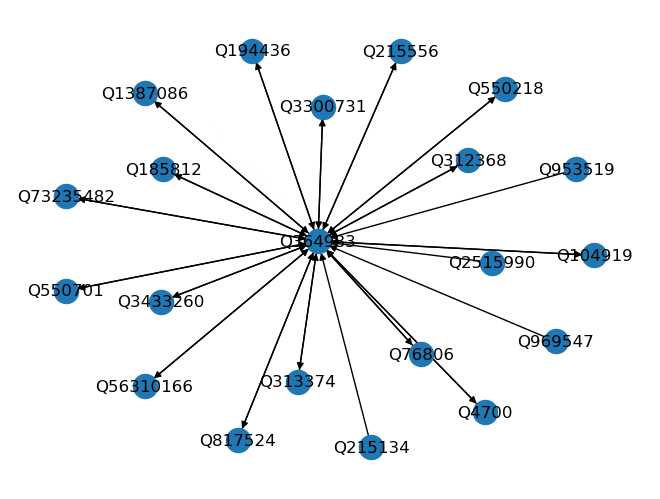

In [9]:
def build_graph_from_adj_list(adj_list,G=nx.DiGraph()):
    #in_G_set = {}
    for compo in adj_list:
        #G.add_node(compo)
        #in_G_set.add(compo)
        for c in adj_list[compo]:
            #if c not in in_G_set:
                #G.add_node(compo)
            G.add_edge(compo,c)
    return G

G=build_graph_from_adj_list(adj_list_sparql)
nx.draw(G, with_labels=True)#, labels = nx.get_node_attributes(graph, 'nom complet'))

In [ ]:
def graph_of_influences(list_of_compo_names):
    list_of_influ_dicts=build_list_of_influences(list_of_compo_names,True)#put false if you're only interested in the english wiki
    adj_list = orienting_with_dates(list_of_influ_dicts)
    return build_graph_from_adj_list(adj_list)
graph_of_influences(["Henri Duparc","John Dunstable"])
    

Henri Duparc is a composer
Maurice Duhamel is a composer
Paul Dukas is a composer
Gabriel Dupont is a composer
Jean-Louis Duport is a composer
Egidio Duni is a composer
John Dunstaple is a composer
Jacques Duphly is a composer
Gabriel Fauré is a composer
Benjamin Godard is a composer
Claude Debussy is a composer
Isaac Albéniz is a composer
Ernest Chausson is a composer
Jules Garcin is a composer
Jacques Lamy is a composer
Rita Strohl is a composer
Vincent d'Indy is a composer
Alexandre Tansman is a composer
Emmanuel Chabrier is a composer
Jules Massenet is a composer
Louis Moreau Gottschalk is a composer
Bussine is a composer
Erreur sur le nom l a
Erreur sur le nom R e
Erreur sur le nom l a
Erreur sur le nom L i
Erreur sur le nom l a
Erreur sur le nom J o
John Dunstaple is a composer
Erreur sur le nom ا ل
Erreur sur le nom C a
Erreur sur le nom B a
Erreur sur le nom L a
William Byrd is a composer
Henry Purcell is a composer
Erreur sur le nom D u
Erreur sur le nom J o
Gilles Binchois is